In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import xgboost
from sklearn.model_selection import TimeSeriesSplit
from sklearn.linear_model import LinearRegression, Lasso, RidgeCV, LassoCV
from sklearn.metrics import mean_squared_error, r2_score, accuracy_score
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.metrics import accuracy_score, classification_report
from sklearn.pipeline import Pipeline


Regression
----

The goal in this notebook is to train an ML model where it tries to predict the number of pitstops an driver completes in an race.

---

In [2]:
pd.set_option('display.max_columns', None)

In [3]:
regression_data = pd.read_csv('/content/drive/MyDrive/DSA210/ML2.csv')
regression_data.head(10)

,Unnamed: 0,driverId,raceId,temp,Track Length (km),Turns,Direction,Circuit Type,grid,circuit_lap_count,avg_lap_time_last5,avg_position_last5,avg_stop_last5,avg_fastestRank_last5,avg_fastestLap_last5,stop
0,19,1,338,21.8,5.278,14,Clockwise,Street,11.0,58,122113.836735,3.00,1.000000,NaN,NaN,2
1,37,1,339,29.9,5.543,15,Clockwise,Race,20.0,56,109733.030436,4.50,1.500000,3.000000,47.000000,1
2,54,1,340,17.3,5.451,16,Clockwise,Race,6.0,56,106797.514338,5.00,1.333333,3.500000,39.500000,4
3,72,1,341,15.1,4.657,14,Clockwise,Race,3.0,66,108686.050932,4.25,2.000000,2.666667,30.666667,1
4,94,1,342,16.2,3.337,19,Clockwise,Street,5.0,78,104384.065746,6.20,1.800000,2.250000,37.750000,1
5,113,1,343,22.8,5.338,14,Anti clockwise,Race,2.0,58,96929.806091,6.60,1.800000,3.800000,43.800000,1
6,135,1,344,18.9,4.361,13,Clockwise,Street,1.0,70,95830.464712,5.60,1.600000,5.600000,45.200000,2
7,157,1,347,16.6,4.574,17,Clockwise,Race,6.0,67,91740.756855,4.60,1.800000,5.200000,51.200000,1
8,179,1,348,22.9,4.381,14,Clockwise,Race,5.0,70,84648.812772,5.00,1.200000,6.000000,61.600000,1
9,201,1,349,10.4,7.004,19,Clockwise,Race,2.0,44,85491.405163,6.20,1.200000,8.600000,54.200000,2


In [4]:
regression_data.drop(columns=['Unnamed: 0', 'driverId'], inplace=True)
regression_data.head(10)

,raceId,temp,Track Length (km),Turns,Direction,Circuit Type,grid,circuit_lap_count,avg_lap_time_last5,avg_position_last5,avg_stop_last5,avg_fastestRank_last5,avg_fastestLap_last5,stop
0,338,21.8,5.278,14,Clockwise,Street,11.0,58,122113.836735,3.00,1.000000,NaN,NaN,2
1,339,29.9,5.543,15,Clockwise,Race,20.0,56,109733.030436,4.50,1.500000,3.000000,47.000000,1
2,340,17.3,5.451,16,Clockwise,Race,6.0,56,106797.514338,5.00,1.333333,3.500000,39.500000,4
3,341,15.1,4.657,14,Clockwise,Race,3.0,66,108686.050932,4.25,2.000000,2.666667,30.666667,1
4,342,16.2,3.337,19,Clockwise,Street,5.0,78,104384.065746,6.20,1.800000,2.250000,37.750000,1
5,343,22.8,5.338,14,Anti clockwise,Race,2.0,58,96929.806091,6.60,1.800000,3.800000,43.800000,1
6,344,18.9,4.361,13,Clockwise,Street,1.0,70,95830.464712,5.60,1.600000,5.600000,45.200000,2
7,347,16.6,4.574,17,Clockwise,Race,6.0,67,91740.756855,4.60,1.800000,5.200000,51.200000,1
8,348,22.9,4.381,14,Clockwise,Race,5.0,70,84648.812772,5.00,1.200000,6.000000,61.600000,1
9,349,10.4,7.004,19,Clockwise,Race,2.0,44,85491.405163,6.20,1.200000,8.600000,54.200000,2


**Feature Changes**

First the categorical variables are converted into dummy variables since regression uses numeric data.

---

In [5]:
regression_one_hot_encoded = pd.get_dummies(regression_data, columns=['Direction', 'Circuit Type'])
regression_one_hot_encoded.head(10)

,raceId,temp,Track Length (km),Turns,grid,circuit_lap_count,avg_lap_time_last5,avg_position_last5,avg_stop_last5,avg_fastestRank_last5,avg_fastestLap_last5,stop,Direction_Anti clockwise,Direction_Clockwise,Circuit Type_Race,Circuit Type_Road,Circuit Type_Street
0,338,21.8,5.278,14,11.0,58,122113.836735,3.00,1.000000,NaN,NaN,2,False,True,False,False,True
1,339,29.9,5.543,15,20.0,56,109733.030436,4.50,1.500000,3.000000,47.000000,1,False,True,True,False,False
2,340,17.3,5.451,16,6.0,56,106797.514338,5.00,1.333333,3.500000,39.500000,4,False,True,True,False,False
3,341,15.1,4.657,14,3.0,66,108686.050932,4.25,2.000000,2.666667,30.666667,1,False,True,True,False,False
4,342,16.2,3.337,19,5.0,78,104384.065746,6.20,1.800000,2.250000,37.750000,1,False,True,False,False,True
5,343,22.8,5.338,14,2.0,58,96929.806091,6.60,1.800000,3.800000,43.800000,1,True,False,True,False,False
6,344,18.9,4.361,13,1.0,70,95830.464712,5.60,1.600000,5.600000,45.200000,2,False,True,False,False,True
7,347,16.6,4.574,17,6.0,67,91740.756855,4.60,1.800000,5.200000,51.200000,1,False,True,True,False,False
8,348,22.9,4.381,14,5.0,70,84648.812772,5.00,1.200000,6.000000,61.600000,1,False,True,True,False,False
9,349,10.4,7.004,19,2.0,44,85491.405163,6.20,1.200000,8.600000,54.200000,2,False,True,True,False,False


**Time Series**

Since F1 races are temporal data, the data is sorted according to the raceId and TimeSeries cross folding will be used. This data leaks are prevented.

---

In [6]:
regression_final = regression_one_hot_encoded.sort_values('raceId')
regression_final.head(10)

,raceId,temp,Track Length (km),Turns,grid,circuit_lap_count,avg_lap_time_last5,avg_position_last5,avg_stop_last5,avg_fastestRank_last5,avg_fastestLap_last5,stop,Direction_Anti clockwise,Direction_Clockwise,Circuit Type_Race,Circuit Type_Road,Circuit Type_Street
1976,337,26.1,5.412,15,13.0,49,112027.488447,17.50,2.50,19.00,33.75,2,False,True,True,False,False
1240,337,26.1,5.412,15,8.0,49,106724.944113,7.00,2.25,5.75,43.00,1,False,True,True,False,False
1631,337,26.1,5.412,15,7.0,49,105406.483155,18.50,1.25,19.75,42.00,1,False,True,True,False,False
2243,337,26.1,5.412,15,23.0,49,142403.392854,19.75,2.25,19.25,46.50,1,False,True,True,False,False
1351,337,26.1,5.412,15,1.0,49,117032.108806,13.00,2.75,10.50,41.25,1,False,True,True,False,False
1599,337,26.1,5.412,15,12.0,49,103824.203298,14.00,2.25,11.75,53.25,1,False,True,True,False,False
411,337,26.1,5.412,15,3.0,49,115263.450773,2.00,2.25,3.75,39.00,1,False,True,True,False,False
1728,337,26.1,5.412,15,15.0,49,105161.507465,21.00,1.00,21.75,41.00,1,False,True,True,False,False
1567,337,26.1,5.412,15,11.0,49,103410.696718,9.75,1.75,14.00,39.25,1,False,True,True,False,False
1174,337,26.1,5.412,15,6.0,49,113130.803091,17.75,2.75,16.50,30.75,1,False,True,True,False,False


In [7]:
tscv = TimeSeriesSplit()

In [8]:
Y = regression_final['stop']
Y.head(5)

,stop
1976,2
1240,1
1631,1
2243,1
1351,1


The np.nan values were dropped in the EDA notebook however just to gurantee some columns are checked again.

---

In [9]:
X = regression_final.drop(columns=['stop', 'raceId']).dropna()
X['avg_fastestRank_last5'] = X['avg_fastestRank_last5'].dropna()
X['avg_fastestLap_last5'] = X['avg_fastestLap_last5'].dropna()
X.head(5)

,temp,Track Length (km),Turns,grid,circuit_lap_count,avg_lap_time_last5,avg_position_last5,avg_stop_last5,avg_fastestRank_last5,avg_fastestLap_last5,Direction_Anti clockwise,Direction_Clockwise,Circuit Type_Race,Circuit Type_Road,Circuit Type_Street
1976,26.1,5.412,15,13.0,49,112027.488447,17.50,2.50,19.00,33.75,False,True,True,False,False
1240,26.1,5.412,15,8.0,49,106724.944113,7.00,2.25,5.75,43.00,False,True,True,False,False
1631,26.1,5.412,15,7.0,49,105406.483155,18.50,1.25,19.75,42.00,False,True,True,False,False
2243,26.1,5.412,15,23.0,49,142403.392854,19.75,2.25,19.25,46.50,False,True,True,False,False
1351,26.1,5.412,15,1.0,49,117032.108806,13.00,2.75,10.50,41.25,False,True,True,False,False


**Models**

First the Linear, OLS, Ridge, Lasso and Polynomial Regression with Lasso are tested.

---

In [10]:
all_splits = list(tscv.split(X, Y))
for i, (train, test) in enumerate(all_splits):

  print(f"Fold {i}")

  regressor = LinearRegression().fit(X.iloc[train], Y.iloc[train])
  y_pred_LR = regressor.predict(X.iloc[test])

  ols = LinearRegression().fit(X.iloc[train], Y.iloc[train])
  y_pred_OLS = ols.predict(X.iloc[test])

  ridge = RidgeCV(alphas=(0.1, 1.0, 10.0)).fit(X.iloc[train], Y.iloc[train])
  y_pred_Ridge = ridge.predict(X.iloc[test])

  lasso = LassoCV(alphas=(0.1, 1.0, 10.0)).fit(X.iloc[train], Y.iloc[train])
  y_pred_Lasso = lasso.predict(X.iloc[test])

  print("Linear Regression")
  print("---------------------------------")
  print(f"Mean squared error: {mean_squared_error(Y.iloc[test], y_pred_LR):.2f}")
  print(f"Coefficient of determination: {r2_score(Y.iloc[test], y_pred_LR):.2f} \n")

  print("OLS")
  print("---------------------------------")
  print(f"Mean squared error: {mean_squared_error(Y.iloc[test], y_pred_OLS):.2f}")
  print(f"Coefficient of determination: {r2_score(Y.iloc[test], y_pred_OLS):.2f} \n")

  print("Ridge")
  print("---------------------------------")
  print(f"Mean squared error: {mean_squared_error(Y.iloc[test], y_pred_Ridge):.2f}")
  print(f"Coefficient of determination: {r2_score(Y.iloc[test], y_pred_Ridge):.2f} \n")

  print("Lasso")
  print("---------------------------------")
  print(f"Mean squared error: {mean_squared_error(Y.iloc[test], y_pred_Lasso):.2f}")
  print(f"Coefficient of determination: {r2_score(Y.iloc[test], y_pred_Lasso):.2f} \n")

  print("Polynomial")
  print("---------------------------------")
  for j in range(2, 4):
    polynomial_lasso = Pipeline([('polynomial', PolynomialFeatures(i)), ('scale', StandardScaler()), ('lasso', LassoCV(alphas=(0.1, 1.0, 10.0)))])
    polynomial_lasso.fit(X.iloc[train], Y.iloc[train])
    y_pred_Poly = polynomial_lasso.predict(X.iloc[test])

    print(f"Mean squared error for Polynomial with degree {j}: {mean_squared_error(Y.iloc[test], y_pred_Poly):.2f}")
    print(f"Coefficient of determination for Polynomial with degree {j}: {r2_score(Y.iloc[test], y_pred_Poly):.2f} \n")

  print("------------------------------------------------------------------------------------- \n")


Fold 0
Linear Regression
---------------------------------
Mean squared error: 1.07
Coefficient of determination: -0.17 

OLS
---------------------------------
Mean squared error: 1.07
Coefficient of determination: -0.17 

Ridge
---------------------------------
Mean squared error: 1.07
Coefficient of determination: -0.16 

Lasso
---------------------------------
Mean squared error: 0.96
Coefficient of determination: -0.05 

Polynomial
---------------------------------
Mean squared error for Polynomial with degree 2: 0.93
Coefficient of determination for Polynomial with degree 2: -0.02 

Mean squared error for Polynomial with degree 3: 0.93
Coefficient of determination for Polynomial with degree 3: -0.02 

------------------------------------------------------------------------------------- 

Fold 1
Linear Regression
---------------------------------
Mean squared error: 1.23
Coefficient of determination: -0.06 

OLS
---------------------------------
Mean squared error: 1.23
Coefficient

**Result Analysis**

From these results it can be seen that linear/polynomial graphs are not creating any good results since at best they produce an R^2 value of 0. Therefore, the goal is to create an model that does not use linearity like decision trees/XGBoost.

---

**Second Model**

In this part an XGBoost model is used to train the data.

---

In [11]:
regression_data.head(10)

,raceId,temp,Track Length (km),Turns,Direction,Circuit Type,grid,circuit_lap_count,avg_lap_time_last5,avg_position_last5,avg_stop_last5,avg_fastestRank_last5,avg_fastestLap_last5,stop
0,338,21.8,5.278,14,Clockwise,Street,11.0,58,122113.836735,3.00,1.000000,NaN,NaN,2
1,339,29.9,5.543,15,Clockwise,Race,20.0,56,109733.030436,4.50,1.500000,3.000000,47.000000,1
2,340,17.3,5.451,16,Clockwise,Race,6.0,56,106797.514338,5.00,1.333333,3.500000,39.500000,4
3,341,15.1,4.657,14,Clockwise,Race,3.0,66,108686.050932,4.25,2.000000,2.666667,30.666667,1
4,342,16.2,3.337,19,Clockwise,Street,5.0,78,104384.065746,6.20,1.800000,2.250000,37.750000,1
5,343,22.8,5.338,14,Anti clockwise,Race,2.0,58,96929.806091,6.60,1.800000,3.800000,43.800000,1
6,344,18.9,4.361,13,Clockwise,Street,1.0,70,95830.464712,5.60,1.600000,5.600000,45.200000,2
7,347,16.6,4.574,17,Clockwise,Race,6.0,67,91740.756855,4.60,1.800000,5.200000,51.200000,1
8,348,22.9,4.381,14,Clockwise,Race,5.0,70,84648.812772,5.00,1.200000,6.000000,61.600000,1
9,349,10.4,7.004,19,Clockwise,Race,2.0,44,85491.405163,6.20,1.200000,8.600000,54.200000,2


In [12]:
regression_data['Direction'] = regression_data['Direction'].astype('category')
regression_data['Circuit Type'] = regression_data['Circuit Type'].astype('category')
Y = regression_data['stop']
X = regression_data.drop(columns=['stop', 'raceId'])

In [13]:
X.head(10)

,temp,Track Length (km),Turns,Direction,Circuit Type,grid,circuit_lap_count,avg_lap_time_last5,avg_position_last5,avg_stop_last5,avg_fastestRank_last5,avg_fastestLap_last5
0,21.8,5.278,14,Clockwise,Street,11.0,58,122113.836735,3.00,1.000000,NaN,NaN
1,29.9,5.543,15,Clockwise,Race,20.0,56,109733.030436,4.50,1.500000,3.000000,47.000000
2,17.3,5.451,16,Clockwise,Race,6.0,56,106797.514338,5.00,1.333333,3.500000,39.500000
3,15.1,4.657,14,Clockwise,Race,3.0,66,108686.050932,4.25,2.000000,2.666667,30.666667
4,16.2,3.337,19,Clockwise,Street,5.0,78,104384.065746,6.20,1.800000,2.250000,37.750000
5,22.8,5.338,14,Anti clockwise,Race,2.0,58,96929.806091,6.60,1.800000,3.800000,43.800000
6,18.9,4.361,13,Clockwise,Street,1.0,70,95830.464712,5.60,1.600000,5.600000,45.200000
7,16.6,4.574,17,Clockwise,Race,6.0,67,91740.756855,4.60,1.800000,5.200000,51.200000
8,22.9,4.381,14,Clockwise,Race,5.0,70,84648.812772,5.00,1.200000,6.000000,61.600000
9,10.4,7.004,19,Clockwise,Race,2.0,44,85491.405163,6.20,1.200000,8.600000,54.200000


In [14]:
Y.head(10)

,stop
0,2
1,1
2,4
3,1
4,1
5,1
6,2
7,1
8,1
9,2


**Hyperparameter Tunning**

Here one of the most important factor is the depth of the tree. Therefore, different depths starting from 4 can be used to determine the depth. However, the depth is not increased significantly since it can cause overfitting.

---

In [15]:
for d in range(4, 10):
  params = {
      'objective': 'reg:squarederror',
      'max_depth': d,
      'learning_rate': 0.02,
      'subsample': 0.8,
      'colsample_bytree': 0.8,
  }
  n=500
  all_splits = list(tscv.split(X, Y))
  for i, (train, test) in enumerate(all_splits):
    print(f"Fold: {i}")
    xgb_train = xgboost.DMatrix(X.iloc[train], Y.iloc[train], enable_categorical=True)
    xgb_test = xgboost.DMatrix(X.iloc[test], enable_categorical=True)
    model = xgboost.train(params=params,dtrain=xgb_train,num_boost_round=n)
    preds = model.predict(xgb_test)
    preds = np.round(preds).clip(1,7)
    print(f"Mean squared error for XGBoost: {mean_squared_error(Y.iloc[test], preds):.2f}")
    print(f"Coefficient of determination for XGBoost: {r2_score(Y.iloc[test], preds):.2f}")
    list_ver = list(model.get_score(importance_type='gain').items())
    sorted_version = sorted(list_ver, key=lambda x: x[1], reverse = True)
    print(f"Parameter Importance Dict: {sorted_version}")
    print("--------------------------- \n")

Fold: 0
Mean squared error for XGBoost: 0.81
Coefficient of determination for XGBoost: 0.21
Parameter Importance Dict: [('Circuit Type', 4.454536437988281), ('circuit_lap_count', 3.7577900886535645), ('Turns', 3.590484619140625), ('avg_stop_last5', 3.0717077255249023), ('Direction', 2.979192018508911), ('Track Length (km)', 2.9305484294891357), ('temp', 2.6620404720306396), ('avg_lap_time_last5', 2.340275764465332), ('avg_fastestLap_last5', 1.869586706161499), ('avg_position_last5', 1.8646304607391357), ('avg_fastestRank_last5', 1.8498855829238892), ('grid', 1.5970985889434814)]
--------------------------- 

Fold: 1
Mean squared error for XGBoost: 0.79
Coefficient of determination for XGBoost: 0.22
Parameter Importance Dict: [('circuit_lap_count', 7.125953674316406), ('Turns', 6.4503583908081055), ('avg_stop_last5', 5.366820335388184), ('Track Length (km)', 5.223677635192871), ('temp', 4.8338541984558105), ('Circuit Type', 4.705057621002197), ('Direction', 4.520793914794922), ('avg_lap

**Result Analysis**

As the number of depth increases the R^2 increases and Mean Square error decreases which is the desired outcome. In this model after depth 7 the results do not increase significantly therefore the larger depths may cause overfitting so depth 7 is selected. Also, in the each fold and depth the feature importances are sorted. Generally the maximum number of laps of a grand prix is selected as the most important feature by the models. Generally the second important feature is the number of turns or the circuit type and it changes in different folds.

---

In [16]:
train_set_index = all_splits[4][0]
test_set_index = all_splits[4][1]


params = {
      'objective': 'reg:squarederror',
      'max_depth': 7,
      'learning_rate': 0.02,
      'subsample': 0.8,
      'colsample_bytree': 0.8,
  }

xgb_train = xgboost.DMatrix(X.iloc[train_set_index], Y.iloc[train_set_index], enable_categorical=True)
xgb_test = xgboost.DMatrix(X.iloc[test_set_index], enable_categorical=True)
model = xgboost.train(params=params,dtrain=xgb_train,num_boost_round=500)
preds = model.predict(xgb_test)
list_ver = list(model.get_score(importance_type='gain').items())
sorted_version = sorted(list_ver, key=lambda x: x[1], reverse = True)


Text(0, 0.5, 'Importance')

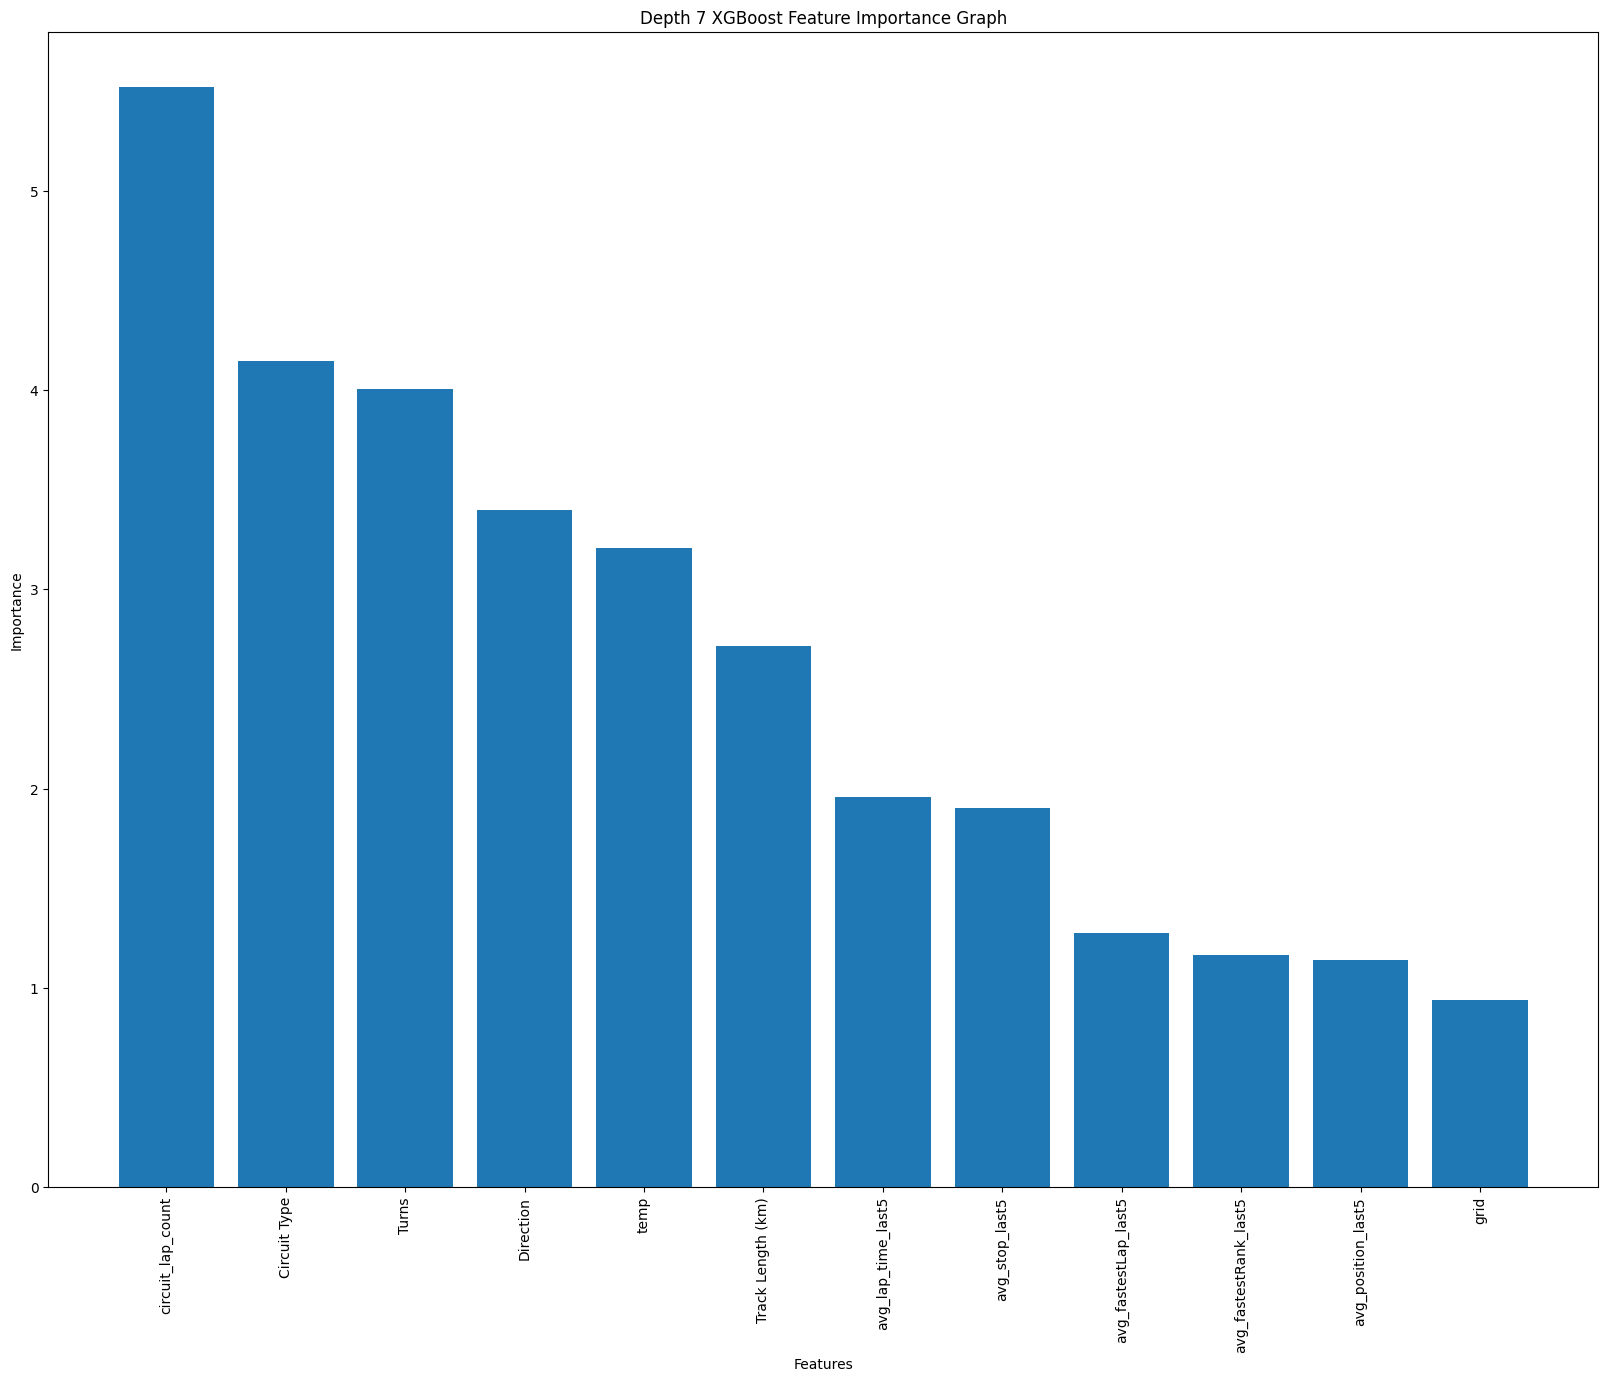

In [20]:
fig, ax = plt.subplots(figsize=(20, 15))
x_val = []
y_val = []
for i in range(0, len(sorted_version)):
  x_val.append(sorted_version[i][0])
  y_val.append(sorted_version[i][1])


ax.bar(x_val, y_val)
ax.tick_params(axis='x', rotation=90)
ax.set_title('Depth 7 XGBoost Feature Importance Graph')
ax.set_xlabel('Features')
ax.set_ylabel('Importance')